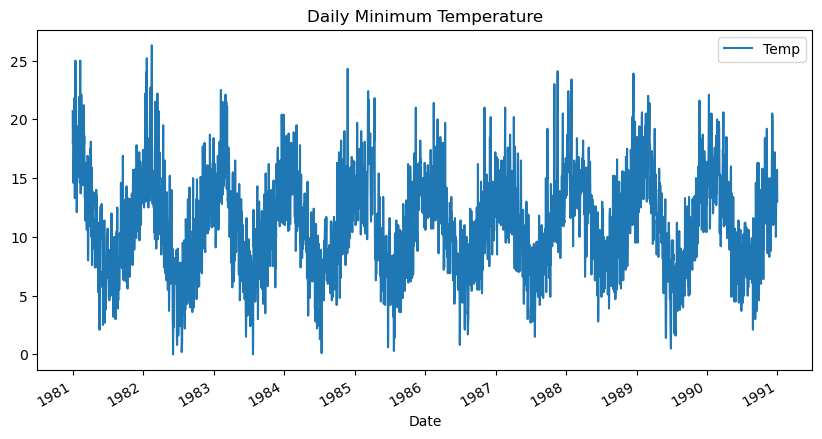

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.plot(figsize=(10,5), title="Daily Minimum Temperature")
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Temp'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.4448049246116925
p-value: 0.000247082630036107


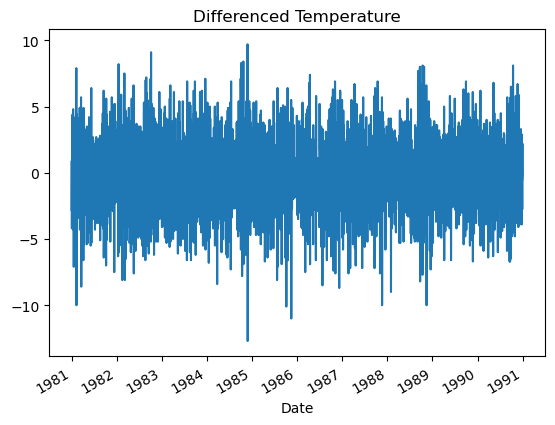

In [4]:
df['diff'] = df['Temp'].diff()

df['diff'].plot(title="Differenced Temperature")
plt.show()

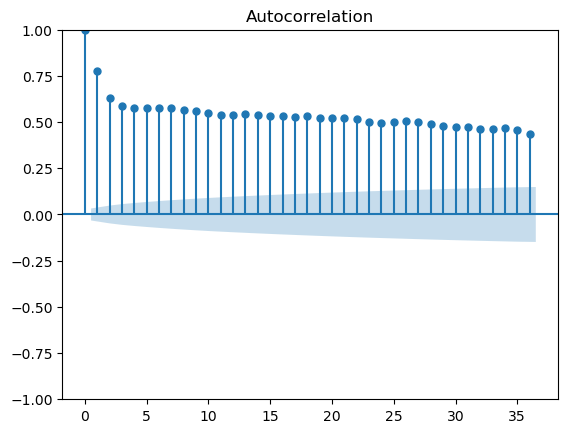

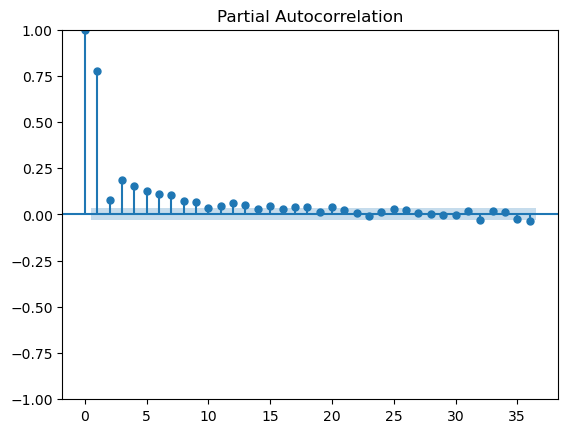

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Temp'].dropna())
plot_pacf(df['Temp'].dropna())
plt.show()

In [6]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Temp'], order=(2,0,2))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressiv

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -8384.568
Date:                Fri, 24 Apr 2026   AIC                          16781.136
Time:                        12:07:12   BIC                          16818.351
Sample:                             0   HQIC                         16794.389
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.4839      0.812     14.147      0.000       9.893      13.075
ar.L1          1.2365      0.040     30.766      0.000       1.158       1.315
ar.L2         -0.2421      0.040     -6.108      0.0

In [7]:
forecast = model_fit.forecast(steps=7)

print(forecast)

3650    12.993672
3651    13.398901
3652    13.486325
3653    13.496328
3654    13.487533
3655    13.474237
3656    13.459926
Name: predicted_mean, dtype: float64


C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


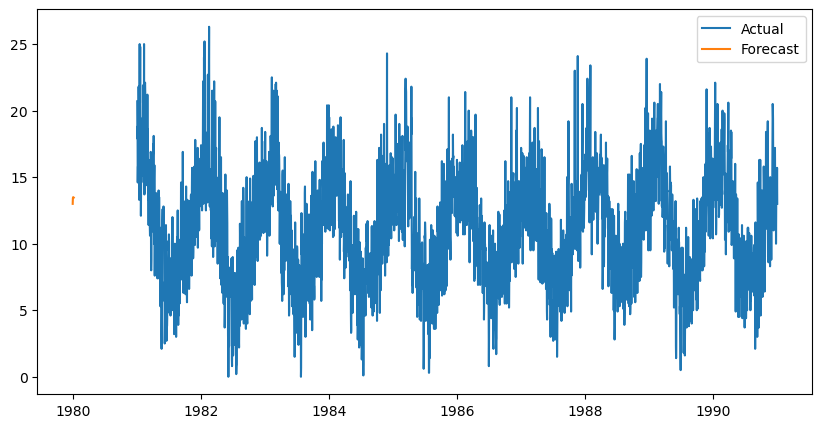

In [8]:
plt.figure(figsize=(10,5))

plt.plot(df['Temp'], label='Actual')
plt.plot(forecast, label='Forecast')

plt.legend()
plt.show()